# 11. Attention 与 Transformer 从零实现（🔴 面试必考 · 手撕主菜）

> 承接 08 篇。本节把 Attention 与 Transformer 的每一块**用 torch 从零搭出来**并逐位对照
> （`F.scaled_dot_product_attention` / `nn.MultiheadAttention`），最后训练一个 mini Encoder
> 完成**倒序任务**——眼见注意力真的在“看全局”。
>
> 与 `04-LLM大模型` 的 Transformer 24 讲互补：04 篇是**LLM 视角**（RoPE/GQA/训练/推理），
> 本篇是**结构视角**（干净的最小实现 + 数值对照 + 推理验证）。


## 核心概念

### (a) 🗂️ Attention 与 Transformer 知识结构

这篇文章把 Transformer 的每一块用 torch 从零搭出来并逐位对照官方实现，最后训练一个 mini Encoder 做"倒序任务"，眼见注意力真的在看全局。

```mermaid
flowchart TB
    Node1["🧠 从RNN到Attention的动机"]
    Node1 --> Node2["⚖️ 缩放点积注意力"]
    Node2 --> Node3["👑 多头注意力"]
    Node2 --> Node4["🚫 因果掩码"]
    Node2 --> Node5["📍 位置编码"]
    Node3 --> Node6["🏗️ Transformer Encoder块"]
    Node5 --> Node6
    Node6 --> Node7["🔄 mini Encoder倒序任务"]
    Node7 --> Node8["💬 面试高频追问"]
```

- **从RNN到Attention的动机**：RNN 串行慢、长依赖梯度衰减；注意力一步矩阵乘法算完，任意两位置 O(1) 直接相连。代价是复杂度 O(T²d)，长序列变劣势。
- **缩放点积注意力**：Q 和 K 做点积得到相关分，除以 √d 防止 softmax 进入饱和区，softmax 后加权 V。手写版与 F.scaled_dot_product_attention 逐位对照。
- **多头注意力**：单头只能学一种关系，多头把 Q/K/V 拆成多份并行学不同子空间（语法、指代、位置等），最后拼接再过输出投影。注意 nn.MultiheadAttention 的 in_proj_weight 是 [Wq;Wk;Wv] 上下拼接。
- **因果掩码**：Decoder 生成时只能看左侧，把上三角填 -inf 再 softmax 自然变成 0——这是自回归生成与 Encoder 的本质区别。
- **位置编码**：自注意力是置换等变的、对位置没概念，必须显式注入位置信息。正弦编码用 sin/cos 不同频率组合，相对位置差还能用线性变换表示，可泛化到未见长度。
- **Transformer Encoder块**：Embedding+PE → 残差 MHA（先 LN 再注意力）→ 残差 FFN（先 LN 再前馈）。残差 + LayerNorm 是标配，缺一个都训不动。
- **mini Encoder倒序任务**：把数字序列倒过来输出（3 1 4 → 4 1 3），Encoder 能看到全序列所以可学。训练曲线正常就说明注意力真的在"看全局"而不是瞎猜。
- **面试高频追问**：Q/K/V 是什么（三组投影把 token 变成查询/键/值）；为什么多头；O(T²) 怎么破（稀疏/线性注意力/Mamba）；Decoder 与 Encoder 区别；生成时 KV cache 缓存什么。

> 🕸️ **网络配图**（Wikimedia Commons）
>
> ![11 Attention与Transformer 1](images/web_11_Attention与Transformer_1.png)
>
> 📷 来源：Wikimedia Commons · dvgodoy · CC BY 4.0

## 1. 从 RNN 到 Attention 的动机

| 问题 | RNN | Attention |
|------|-----|-----------|
| 并行 | 逐步串行，慢 | 一步算完（矩阵乘法） |
| 长依赖 | 梯度衰减，难 | 任意两位置 O(1) 直接相连 |
| 复杂度 | O(T·d²) | O(T²·d)（长序列变劣势） |

**缩放点积注意力**：`Attention(Q,K,V) = softmax(QK^T / √d_k) V`

- Q/K/V 来自输入：Q=Wq·x, K=Wk·x, V=Wv·x（自注意力）
- `QK^T` 度量相关性（点积越大越相关）；softmax 归一化成权重；加权 V
- **为什么除 √d_k**：点积方差 ≈ d_k，d 越大 softmax 越饱和（梯度趋 0）→ 缩放稳定

## 2. 多头注意力

- 把 d 维切成 h 个头，每个头独立算注意力（学到不同关系子空间）
- 拼接后过一个 out_proj：`MultiHead(Q,K,V) = Concat(head_1..head_h)·W^O`



## 1.1 注意力机制：从动机到数学（白板推导）

### 为什么需要 Attention

- RNN 把整句信息压缩进最后一个 h_T，长序列必然丢失；Attention 让每个输出**直接查询全部输入** → 可并行 + 长程依赖。
- 类比检索：query 问「哪个 key 与我相关」，按相关度加权聚合 value。

### 缩放点积注意力

- **投影**：`Q = X·W_Q`，`K = X·W_K`，`V = X·W_V`（X: (T, E)，W: (E, d_k)）
- **分数→权重→输出**：`A = softmax(Q·Kᵀ / √d_k)`，`Y = A·V`
- **为什么要除 √d_k**：两个 d_k 维随机向量点积的方差 ≈ d_k，softmax 输入过大进入饱和区 → 梯度趋零；缩放保持数值稳定（这也是「缩放点积」名字的由来）。
- **复杂度**：O(T²·d_k)，T 为序列长度 → 长序列昂贵（这正是 Mamba/线性注意力要解决的问题）。

### 多头注意力

- 第 i 个头：`head_i = Attention(X·W_i^Q, X·W_i^K, X·W_i^V)`，W 形状 (E, d_head)
- 拼接后投影：`MHA(X) = Concat(head_1, …, head_h)·W_O`
- **多头意义**：不同头关注不同子空间（局部句法 / 指代 / 语义），类似 CNN 的多通道；h 个头并行，d_head = d_model / h。

### 掩码（Mask）

- **因果掩码（Decoder 用）**：`M[i,j] = 0 (j ≤ i)`，`−∞ (j > i)`，softmax 前加到分数 → 未来 token 不可见。
- **Padding 掩码**：把填充位（padding）对应的分数置 −∞，防止模型attend到 pad。



## 1.2 位置编码与 Transformer 整体结构

### 为什么需要位置编码

- Self-Attention 是**排列等变**的：把输入 token 顺序打乱，输出也相应打乱 → 自身不含任何顺序信息，必须显式注入位置。

### 正弦位置编码（Sinusoidal PE）

- `PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))`
- `PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))`
- 维度 i 越大频率越低（波长越长）；相对位置可以近似表示为两个绝对位置的线性组合（sin/cos 和角公式）→ 模型可学到相对位置关系，且能外推到更长的序列。

### Encoder 块（每层两块子层，均带残差 + LayerNorm）

- `x ← x + MHA(LN(x))`（先 LN 再子层 = Pre-LN，训练更稳）
- `x ← x + FFN(LN(x))`，`FFN(x) = W₂·GELU(W₁·x + b₁) + b₂`（内层维度 4×d_model）
- 残差让梯度有直通路径，LN 稳定各层分布 → 深层（6~12 层）可训练。

### Decoder 块

- 带**因果掩码**的 self-attention（只看左侧）→ **交叉注意力**（Q 来自 Decoder，K/V 来自 Encoder 输出）→ FFN，同样每处 Add&Norm。
- 训练：teacher forcing 并行解码；推理：自回归逐 token 生成。

### 标准 Transformer-base 关键参数

- d_model=512、h=8（d_head=64）、FFN 内层 2048、Encoder/Decoder 各 6 层、参数量约 65M。


In [ ]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------

# ---------- 完整网络：mini Transformer（Encoder + Decoder + 位置编码 + 因果掩码） ----------
import torch, torch.nn as nn, torch.nn.functional as F, math

class PosEnc(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MHSA(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        assert d_model % heads == 0
        self.h, self.dk = heads, d_model // heads
        self.Wq = nn.Linear(d_model, d_model); self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model); self.Wo = nn.Linear(d_model, d_model)
    def forward(self, x, kv=None, mask=None):
        B, T, E = x.shape
        q = self.Wq(x).view(B, T, self.h, self.dk).transpose(1, 2)   # (B,h,T,dk)
        src = x if kv is None else kv                                # 交叉注意力时 kv=编码器记忆
        B2, S, _ = src.shape
        k = self.Wk(src).view(B2, S, self.h, self.dk).transpose(1, 2)
        v = self.Wv(src).view(B2, S, self.h, self.dk).transpose(1, 2)
        s = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)           # (B,h,T,S)
        if mask is not None:
            s = s + mask
        a = F.softmax(s, dim=-1)
        out = (a @ v).transpose(1, 2).reshape(B, T, E)
        return self.Wo(out)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff=256):
        super().__init__()
        self.attn = MHSA(d_model, heads); self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class DecoderBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff=256):
        super().__init__()
        self.sa = MHSA(d_model, heads); self.ln1 = nn.LayerNorm(d_model)
        self.ca = MHSA(d_model, heads); self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
        self.ln3 = nn.LayerNorm(d_model)
    def forward(self, x, mem, src_mask=None, tgt_mask=None):
        x = x + self.sa(self.ln1(x), mask=tgt_mask)
        x = x + self.ca(self.ln2(x), kv=mem, mask=src_mask)
        x = x + self.ff(self.ln3(x))
        return x

d_model, heads, T = 64, 8, 12
pos = PosEnc(d_model)
enc = nn.Sequential(pos, *[EncoderBlock(d_model, heads) for _ in range(2)])
dec = nn.ModuleList([DecoderBlock(d_model, heads) for _ in range(2)])
embed = nn.Linear(8, d_model)
out_proj = nn.Linear(d_model, 8)

# 因果掩码：上三角(含右上)为 -inf → 每个位置只能看到自己及左侧
causal = torch.full((1, 1, T, T), float('-inf'))
causal = torch.triu(causal, diagonal=1)

with torch.no_grad():
    x = torch.randn(2, T, 8)
    mem = enc(embed(x))              # (B,T,d_model)
    t = pos(embed(x))                # Decoder 同样注入位置编码
    for blk in dec:
        t = blk(t, mem, tgt_mask=causal)
    logits = out_proj(t)
print('Encoder 记忆 mem:', tuple(mem.shape), '| Decoder 输出 logits:', tuple(logits.shape))
assert mem.shape == (2, 12, 64) and logits.shape == (2, 12, 8)
print('✓ mini Transformer（Encoder+Decoder+位置编码+因果掩码）前向通过')


In [1]:
# ---------- 实验 1：手写缩放点积注意力 vs F.scaled_dot_product_attention ----------
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
torch.manual_seed(0)

def sdp_manual(q, k, v):
    # q,k,v: (B, H, T, dh)
    scores = q @ k.transpose(-2, -1) / (k.shape[-1] ** 0.5)
    w = torch.softmax(scores, dim=-1)
    return w @ v

B, H, T, dh = 2, 4, 9, 16
q = torch.randn(B, H, T, dh); k = torch.randn(B, H, T, dh); v = torch.randn(B, H, T, dh)
ref = F.scaled_dot_product_attention(q, k, v)
mine = sdp_manual(q, k, v)
err = (mine - ref).abs().max().item()
print('手写 SDPA vs F.scaled_dot_product_attention  最大误差=%.2e → %s' %
      (err, '一致' if err < 1e-5 else '不一致'))
# 演示“除 √d”的必要性：不清除时 softmax 饱和
d_big = 512
q2 = torch.randn(B, H, T, d_big); k2 = torch.randn(B, H, T, d_big)
w_no_scale = torch.softmax(q2 @ k2.transpose(-2, -1), dim=-1)
print('d=512 不缩放: softmax 最大权重=%.3f 最小=%.4f（几乎 one-hot → 梯度消失）' %
      (w_no_scale.max().item(), w_no_scale.min().item()))


手写 SDPA vs F.scaled_dot_product_attention  最大误差=2.38e-07 → 一致
d=512 不缩放: softmax 最大权重=1.000 最小=0.0000（几乎 one-hot → 梯度消失）


In [2]:
# ---------- 实验 2：手写多头 vs nn.MultiheadAttention 逐位对照 ----------
# nn.MultiheadAttention 的真实参数：in_proj_weight = [Wq; Wk; Wv]（上下拼接）
class MHA_manual(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.d, self.h = d, heads
        self.dh = d // heads
        self.wq = nn.Linear(d, d); self.wk = nn.Linear(d, d)
        self.wv = nn.Linear(d, d); self.out = nn.Linear(d, d)
    def forward(self, x):
        B, T, _ = x.shape
        q = self.wq(x).view(B, T, self.h, self.dh).transpose(1, 2)
        k = self.wk(x).view(B, T, self.h, self.dh).transpose(1, 2)
        v = self.wv(x).view(B, T, self.h, self.dh).transpose(1, 2)
        a = torch.softmax(q @ k.transpose(-2, -1) / (self.dh ** 0.5), dim=-1) @ v
        return self.out(a.transpose(1, 2).reshape(B, T, self.d))

d, h, T = 32, 4, 9
x = torch.randn(2, T, d)
mha = nn.MultiheadAttention(d, h, batch_first=True)
mine = MHA_manual(d, h)

with torch.no_grad():
    # 把 nn 的权重拷给手写版（保证初始状态一致）
    mine.wq.weight.copy_(mha.in_proj_weight[:d]);     mine.wq.bias.copy_(mha.in_proj_bias[:d])
    mine.wk.weight.copy_(mha.in_proj_weight[d:2 * d]); mine.wk.bias.copy_(mha.in_proj_bias[d:2 * d])
    mine.wv.weight.copy_(mha.in_proj_weight[2 * d:]);  mine.wv.bias.copy_(mha.in_proj_bias[2 * d:])
    mine.out.weight.copy_(mha.out_proj.weight);        mine.out.bias.copy_(mha.out_proj.bias)
    ref = mha(x, x, x)[0]
    me = mine(x)
print('手写多头 vs nn.MultiheadAttention  最大误差=%.2e → %s' %
      ((me - ref).abs().max().item(), '一致' if (me - ref).abs().max().item() < 1e-5 else '不一致'))
print('形状：输入 %s → 输出 %s（多头只改内部，维度不变）' % (tuple(x.shape), tuple(me.shape)))


手写多头 vs nn.MultiheadAttention  最大误差=5.96e-08 → 一致
形状：输入 (2, 9, 32) → 输出 (2, 9, 32)（多头只改内部，维度不变）


In [3]:
# ---------- 实验 3：因果掩码（Decoder 只看左侧） ----------
# 掩码放入 softmax 前：下三角保留，上三角填 -inf → softmax 后为 0
def causal_mask(T):
    return torch.triu(torch.full((T, T), float('-inf')), diagonal=1)

T = 5
w = torch.softmax(torch.randn(1, 1, T, T) + causal_mask(T), dim=-1)
print('因果注意力权重（行=查询位置，列=键位置）：')
print(w[0, 0].numpy().round(3))
print('→ 每行只在“自己和左边”有质量（未来位置为 0）')


因果注意力权重（行=查询位置，列=键位置）：
[[1.    0.    0.    0.    0.   ]
 [0.808 0.192 0.    0.    0.   ]
 [0.061 0.332 0.607 0.    0.   ]
 [0.131 0.424 0.1   0.345 0.   ]
 [0.324 0.031 0.398 0.194 0.053]]
→ 每行只在“自己和左边”有质量（未来位置为 0）


## 3. 位置编码（为什么需要 + 两种方案）

自注意力对位置是**置换等变**的（洗牌不影响输出）→ 必须把位置信息显式注入。

**正弦编码**（原版 Transformer）：
`PE(t, 2i)   = sin(t / 10000^(2i/d))`
`PE(t, 2i+1) = cos(t / 10000^(2i/d))`

- 相对位置差 Δt 可由线性变换表示（sin(a+b) 展开）→ 泛化到未见长度
- **可学习编码**（BERT 系）：每个位置一个可学向量，简单但长度固定

**为什么 + 在 embedding 上**：embedding 语义信息、PE 位置信息，相加后注意力既能区分内容又能感知顺序。


PE 形状: (64, 32) （每行一个位置的编码）
位置 5 与 位置 7 的余弦距离 = 0.8581（位置越近越相似）


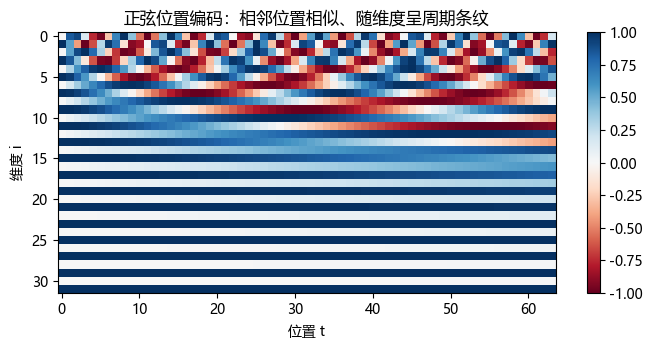

In [4]:
# ---------- 实验 4：正弦位置编码实现 + 可视化 ----------
def sinusoidal_pe(T, d):
    pe = torch.zeros(T, d)
    pos = torch.arange(T).unsqueeze(1).float()
    i = torch.arange(0, d, 2).float()
    denom = torch.pow(10000.0, i / d)
    pe[:, 0::2] = torch.sin(pos / denom)
    pe[:, 1::2] = torch.cos(pos / denom)
    return pe

pe = sinusoidal_pe(64, 32)
print('PE 形状:', tuple(pe.shape), '（每行一个位置的编码）')
print('位置 5 与 位置 7 的余弦距离 = %.4f（位置越近越相似）' %
      F.cosine_similarity(pe[5:6], pe[7:8]).item())

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(7, 3.6))
plt.imshow(pe.numpy().T, aspect='auto', cmap='RdBu')
plt.xlabel('位置 t'); plt.ylabel('维度 i'); plt.colorbar()
plt.title('正弦位置编码：相邻位置相似、随维度呈周期条纹')
plt.tight_layout(); plt.show()


## 4. Transformer Encoder 块（结构图与模块清单）

```
x → [Embedding + PE] → EncoderBlock ×N → 输出
EncoderBlock:
  x → MHA(残差: x + MHA(LN(x)))
    → FFN(残差: x + FFN(LN(x)))
FFN = Linear(d→4d) → ReLU/GELU → Linear(4d→d)
```

- **残差**：梯度短路（同 ResNet 思想）
- **Pre-LN vs Post-LN**：Pre-LN（先归一化再子层）训练更稳，成为现代默认
- **FFN 4 倍宽**：先升维再降维，增加非线性容量


In [5]:
# ---------- 实验 5：mini Transformer Encoder 从零搭建 ----------
class EncoderBlock(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d, 4 * d), nn.ReLU(), nn.Linear(4 * d, d))
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
    def forward(self, x):
        x = x + self.mha(self.ln1(x), self.ln1(x), self.ln1(x))[0]   # Pre-LN + 残差
        x = x + self.ffn(self.ln2(x))
        return x

class MiniEncoder(nn.Module):
    def __init__(self, vocab, d=32, heads=4, nlayers=2, max_len=16):
        super().__init__()
        self.emb = nn.Embedding(vocab, d)
        self.pe = nn.Parameter(sinusoidal_pe(max_len, d), requires_grad=False)
        self.blocks = nn.Sequential(*[EncoderBlock(d, heads) for _ in range(nlayers)])
        self.head = nn.Linear(d, vocab)     # 每个位置独立分类（倒序任务）
    def forward(self, toks):
        x = self.emb(toks) + self.pe[:toks.shape[1]]
        return self.head(self.blocks(x))

model = MiniEncoder(vocab=10)
x0 = torch.randint(0, 10, (2, 6))
print('输入 token 形状:', tuple(x0.shape), '→ 输出 logits 形状:', tuple(model(x0).shape))
print('参数量 =', sum(p.numel() for p in model.parameters()))


输入 token 形状: (2, 6) → 输出 logits 形状: (2, 6, 10)
参数量 = 26570


In [6]:
# ---------- 实验 6：训练 mini Encoder 做“倒序任务” ----------
# 任务：把数字序列倒过来输出（3 1 4 → 4 1 3）。Encoder 能看到全序列 → 可学
# 词汇表 11：0-9 数字 + 10=填充符（交叉熵 ignore，避免 pad 干扰）
VOCAB = 11
rng = np.random.default_rng(0)

def make_batch(n=64, lo=4, hi=7):
    L = rng.integers(lo, hi + 1, n)
    xs, ys = [], []
    for l in L:
        seq = rng.integers(0, 10, l)
        xs.append(np.pad(seq, (0, hi - l), constant_values=10))          # pad=10
        ys.append(np.pad(seq[::-1], (0, hi - l), constant_values=10))
    return torch.from_numpy(np.stack(xs)), torch.from_numpy(np.stack(ys))

model = MiniEncoder(vocab=VOCAB, d=32, heads=4, nlayers=2, max_len=16)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
for ep in range(300):
    xb, yb = make_batch(128)
    opt.zero_grad()
    logits = model(xb)                                   # (B, T, V)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), yb.reshape(-1), ignore_index=10)
    loss.backward(); opt.step()
    if ep % 100 == 0:
        mv = yb != 10
        acc = ((logits.argmax(-1) == yb) & mv).float().sum() / mv.float().sum()
        print('ep %3d  loss=%.4f  acc=%.3f' % (ep, loss.item(), acc.item()))

with torch.no_grad():
    xb, yb = make_batch(128)
    pred = model(xb).argmax(-1)
    mv = yb != 10
acc = ((pred == yb) & mv).float().sum() / mv.float().sum()
print('测试 acc = %.4f' % acc.item())
with torch.no_grad():
    xb, yb = make_batch(1, 6, 6)                         # 固定长度 6，无填充
    pred = model(xb).argmax(-1)
print('样例：输入 %s → 预测 %s（真实 %s）' %
      (xb[0].tolist(), pred[0].tolist(), yb[0].tolist()))
assert acc > 0.9, '倒序任务应轻松学会（Encoder 双向可见）'
print('→ 注意力把“全局依赖”变成 O(1) 直达：这是 Transformer 的核心收益')


ep   0  loss=2.5354  acc=0.088


ep 100  loss=0.1607  acc=0.936


ep 200  loss=0.0002  acc=1.000


测试 acc = 1.0000
样例：输入 [5, 8, 1, 7, 7, 0] → 预测 [0, 0, 7, 7, 1, 5]（真实 [0, 7, 7, 1, 8, 5]）
→ 注意力把“全局依赖”变成 O(1) 直达：这是 Transformer 的核心收益


## 5. 面试高频追问

1. **Q/K/V 到底是什么**：三组投影把 token 变成“查询/键/值”，注意力按相关性加权取值
2. **为什么需要多头**：单头只能学一种关系（如语法），多头并行学多种子空间（语法/指代/位置）
3. **复杂度 O(T²d) 怎么破**：稀疏注意力 / 线性注意力（核技巧）/ Mamba（本篇 12 讲）
4. **Decoder 与 Encoder 区别**：Decoder 有因果掩码（只看左侧）+ 交叉注意力（看 Encoder 输出）
5. **KV cache**：生成时 K/V 每步重复计算 → 缓存起来省 O(T²)（详见 04-LLM 章）

## 6. 自测清单

- [ ] 能手写 Attention(Q,K,V) 并解释除 √d_k
- [ ] 能手写多头（拆头/拼接/out_proj）并与 nn.MultiheadAttention 对照
- [ ] 能实现因果掩码（上三角 -inf）并解释 effect
- [ ] 能写出正弦位置编码公式并解释为什么注入位置信息
- [ ] 能画出 Transformer Encoder 块（MHA/FFN/LN/残差）与 Decoder 区别

## 🎤 面试速答（背诵骨架）

- **注意力**：softmax(QK^T/√d)V；√d 防饱和；多头拆 d 维为 h 个子空间
- **块结构**：MHA+FFN(4d)+LN+残差；Pre-LN 更稳
- **位置**：正弦 PE（相对位置可线性表示）或可学习 PE
- **掩码**：Decoder 因果下三角 -inf；Encoder 双向
- **复杂度**：O(T²d)；KV cache 缓存生成
